In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras

In [3]:
df = pd.read_csv("data/DailyDelhiClimateTest.csv")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

In [4]:
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-01,15.913043,85.869565,2.743478,59.000000
2017-01-02,18.500000,77.222222,2.894444,1018.277778
2017-01-03,17.111111,81.888889,4.016667,1018.333333
2017-01-04,18.700000,70.050000,4.545000,1015.700000
2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [6]:
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)

In [22]:
scaled_df

array([[0.20906568, 0.87239571, 0.07563979, 0.        ],
       [0.31914894, 0.76165066, 0.08406105, 0.99529809],
       [0.26004728, 0.82141587, 0.14666135, 0.99535573],
       [0.32765957, 0.66979723, 0.17613308, 0.99262352],
       [0.3144208 , 0.73247954, 0.10668393, 0.99120553],
       [0.35396518, 0.78849326, 0.40689493, 0.98854878],
       [0.15780142, 1.        , 0.48275061, 0.98813612],
       [0.19932811, 0.84238611, 0.03137763, 0.99246789],
       [0.15197568, 0.80759262, 0.28757844, 0.99288538],
       [0.04728132, 0.69405905, 0.44478755, 0.99385705],
       [0.        , 0.69619353, 0.46772034, 0.99374177],
       [0.03359462, 0.72779869, 0.29223397, 0.99331704],
       [0.0951189 , 0.63148974, 0.28157832, 0.99452162],
       [0.09361702, 0.72397012, 0.21691005, 0.99588142],
       [0.23126735, 0.70200919, 0.12511639, 0.99514521],
       [0.15531915, 0.7773746 , 0.50162367, 0.99412796],
       [0.03073286, 0.85414443, 0.37103076, 0.99541337],
       [0.08687943, 0.77588047,

In [18]:
scaled_df.shape

(114, 4)

In [23]:
scaled_df[0, 0]

np.float64(0.20906567992599445)

In [7]:
def create_sequence(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window, 0])
    return np.array(X), np.array(y)

In [8]:
X, y = create_sequence(scaled_df, 20)

In [11]:
print(X.shape)
print(y.shape)

(94, 20, 4)
(94,)


In [17]:
print(f"X : {X}")
print(f"y : {y}")

X : [[[0.20906568 0.87239571 0.07563979 0.        ]
  [0.31914894 0.76165066 0.08406105 0.99529809]
  [0.26004728 0.82141587 0.14666135 0.99535573]
  ...
  [0.08687943 0.77588047 0.25892353 0.99911685]
  [0.15400203 0.73502058 0.49928612 1.        ]
  [0.18141097 0.62399596 0.54883323 0.99894165]]

 [[0.31914894 0.76165066 0.08406105 0.99529809]
  [0.26004728 0.82141587 0.14666135 0.99535573]
  [0.32765957 0.66979723 0.17613308 0.99262352]
  ...
  [0.15400203 0.73502058 0.49928612 1.        ]
  [0.18141097 0.62399596 0.54883323 0.99894165]
  [0.18686401 0.68029326 0.68657886 0.9975812 ]]

 [[0.26004728 0.82141587 0.14666135 0.99535573]
  [0.32765957 0.66979723 0.17613308 0.99262352]
  [0.3144208  0.73247954 0.10668393 0.99120553]
  ...
  [0.18141097 0.62399596 0.54883323 0.99894165]
  [0.18686401 0.68029326 0.68657886 0.9975812 ]
  [0.31659574 0.7490715  0.24993326 0.99816403]]

 ...

 [[0.79787234 0.20490928 0.43928678 0.98074358]
  [0.82978723 0.15368196 0.30959259 0.98074358]
  [0.8

In [28]:
train_split = int(0.85 * len(X))
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

In [31]:
print(X_train.shape)
print(X_test.shape)

(79, 20, 4)
(15, 20, 4)


In [32]:
model = keras.Sequential()
model.add(keras.layers.LSTM(
    100, input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1))
model.compile(loss="mse", optimizer="adam", metrics=["mae"])
model.summary()

/Users/dinith/miniforge3/envs/dtl/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,101 (164.46 KB)

 Trainable params: 42,101 (164.46 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.fit(X_train, y_train, epochs=30, batch_size=16)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0954 - mae: 0.2472  
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0543 - mae: 0.2014
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0319 - mae: 0.1313
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0203 - mae: 0.1223
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0212 - mae: 0.1177
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0220 - mae: 0.1226 
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0172 - mae: 0.1100 
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0140 - mae: 0.0976
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0171 - mae: 0.1093
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0152 - mae: 0.1023 
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0128 - mae: 0.0930
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0154 - mae: 0.1031 
Epoch 13/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0148 - m

In [35]:
pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [38]:
y_test_inv = scaler.inverse_transform(
    np.c_[y_test, np.zeros((len(y_test), df.shape[1]-1))]
)[:, 0]
pred_inv = scaler.inverse_transform(
    np.c_[pred, np.zeros((len(pred), df.shape[1]-1))]
)[:, 0]

In [40]:
mse = mean_squared_error(y_test_inv, pred_inv)
mae = mean_absolute_error(y_test_inv, pred_inv)
rsq = r2_score(y_test_inv, pred_inv)
print(f"mse : {mse},\nmae : {mae},\nrsq : {rsq}")

mse : 6.803098189086041,
mae : 2.1467678725214867,
rsq : -0.7128109672003147


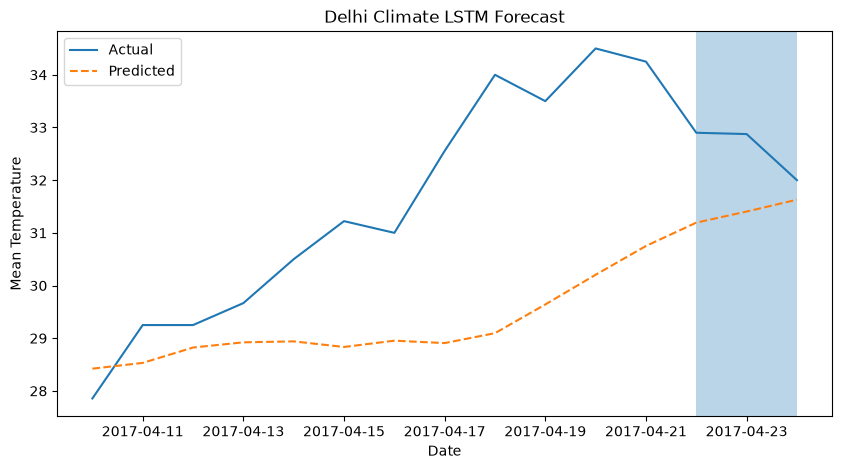

In [42]:
time = df.index[-len(y_test):]
plt.figure(figsize=(10, 5))
plt.plot(time, y_test_inv, label="Actual")
plt.plot(time, pred_inv, linestyle="--", label="Predicted")

highlight = int(len(time) * 0.85)
plt.axvspan(time[highlight], time[-1], alpha=0.3)

plt.title("Delhi Climate LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()